In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statistics
import tensorflow as tf
import os
# from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from xgboost import XGBClassifier, XGBRegressor
from sklearn.metrics import accuracy_score, mean_squared_error
from tensorflow.keras.regularizers import l2
from collections import Counter
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Conv2D, BatchNormalization, Activation, MaxPooling2D, Flatten, Dense, Dropout

In [ ]:
pad_df=pd.read_csv("/kaggle/input/paddy-tab/Paddy_Dataset - Paddy_Dataset.csv")

In [ ]:
pad_dff = pad_df.drop(['PADDY_BIN', 'crop_type'], axis=1)
pad_dff.head()

In [ ]:
pad_dff.info()

In [ ]:
plt.figure(figsize=(12, 6))
pad_dff['YIELD'].value_counts().sort_index().plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('Distribution of YIELD Values', fontsize=14, fontweight='bold')
plt.xlabel('YIELD', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
cd = pad_dff.drop(['UNIQUE_ID', 'SPLIT', 'file'], axis=1).corr()
cd

✅ Yes, models like XGBoost, LightGBM, Random Forest:
- 🔹 Automatically handle feature selection internally during training
- 🔹 By evaluating the information gain or feature importance at each split
- 🔹 They ignore irrelevant or weakly contributing features naturally

So:

- ✅ You can train them directly with all features
- ✅ They’ll “choose” the important features internally

In [ ]:
plt.figure(figsize=(14,4.3))
sns.heatmap(cd, linewidth=0.5, annot=True, cmap='coolwarm')

In [ ]:
tab=pad_dff.drop(['sow_period', 'HARVESTING_DAY', 'start_mon', 'end_mon'], axis=1)

In [ ]:
tab

### Process the images with the required bands

In [ ]:
data = np.load("/kaggle/input/paddydataset/Paddy_Dataset_L8/1196/LC08_142052_20200605.npz")

print("Keys in dataset:", data.files)

for key in data.files:
    print(f"{key}: {data[key].shape}, {data[key].dtype}")

if 'yield' in data.files:
    print("Yield data sample:", data['yield'])
elif 'label' in data.files:
    print("Label data sample:", data['label'])
elif 'target' in data.files:
    print("Target data sample:", data['target'])


In [ ]:
# def load_images_tabular_data(base_folder, target_bands=['SR_B4', 'SR_B5', 'SR_B6', 'ST_B10', 'ST_TRAD'], image_size=(12, 12)):
#     X_img, crop_ids, file_names = [], [], []

#     unique_folders = [f for f in os.listdir(base_folder) if os.path.isdir(os.path.join(base_folder, f))]

#     for crop_id in unique_folders: 
#         crop_folder = os.path.join(base_folder, crop_id)
#         npz_files = sorted([f for f in os.listdir(crop_folder) if f.endswith('.npz')])  

#         for npz_file in npz_files:  
#             file_path = os.path.join(crop_folder, npz_file)
#             data = np.load(file_path)

#             img_stack = []
#             for band in target_bands:
#                 if band in data:
#                     band_img = data[band].astype(np.float32)

#                     h, w = band_img.shape

#                     pad_h = max(0, 12 - h)
#                     pad_w = max(0, 12 - w)
#                     band_img = np.pad(band_img, ((0, pad_h), (0, pad_w)), mode='constant', constant_values=0)

#                     mean, std = np.mean(band_img), np.std(band_img)
#                     band_img = (band_img - mean) / std if std > 0 else np.zeros_like(band_img)

#                     img_stack.append(band_img)

#             if len(img_stack) == len(target_bands):
#                 X_img.append(np.stack(img_stack, axis=-1))  
#                 crop_ids.append(crop_id)
#                 file_names.append(npz_file)  

#     return np.array(X_img), crop_ids, unique_folders, file_names 

def load_images_tabular_data(base_folder, 
                             target_bands=['SR_B4', 'SR_B5', 'SR_B6', 'ST_B10', 'ST_TRAD'], 
                             image_size=(12, 12)):
    X_img, crop_ids, file_names, ndvi_list = [], [], [], []

    unique_folders = [f for f in os.listdir(base_folder) if os.path.isdir(os.path.join(base_folder, f))]

    for crop_id in unique_folders: 
        crop_folder = os.path.join(base_folder, crop_id)
        npz_files = sorted([f for f in os.listdir(crop_folder) if f.endswith('.npz')])  

        for npz_file in npz_files:  
            file_path = os.path.join(crop_folder, npz_file)
            data = np.load(file_path)

            img_stack = []
            raw_b4, raw_b5 = None, None  # placeholders for NDVI bands

            for band in target_bands:
                if band in data:
                    band_img = data[band].astype(np.float32)

                    h, w = band_img.shape
                    pad_h = max(0, 12 - h)
                    pad_w = max(0, 12 - w)
                    band_img = np.pad(band_img, ((0, pad_h), (0, pad_w)), mode='constant', constant_values=0)

                    # keep raw copies for NDVI
                    if band == "SR_B4":
                        raw_b4 = band_img.copy()
                    if band == "SR_B5":
                        raw_b5 = band_img.copy()

                    # normalize for CNN
                    mean, std = np.mean(band_img), np.std(band_img)
                    band_img = (band_img - mean) / std if std > 0 else np.zeros_like(band_img)

                    img_stack.append(band_img)

            # Only add if all bands present
            if len(img_stack) == len(target_bands):
                X_img.append(np.stack(img_stack, axis=-1))  
                crop_ids.append(crop_id)
                file_names.append(npz_file)

                # --- Compute NDVI (use raw reflectance, not normalized) ---
                if raw_b4 is not None and raw_b5 is not None:
                    ndvi = (raw_b5 - raw_b4) / (raw_b5 + raw_b4 + 1e-6)
                    ndvi_mean = float(np.nanmean(ndvi))  # single value per image
                else:
                    ndvi_mean = np.nan
                ndvi_list.append(ndvi_mean)

    return np.array(X_img), crop_ids, unique_folders, file_names, ndvi_list


In [ ]:
# Call the function
base_folder = "/kaggle/input/paddydataset/Paddy_Dataset_L8"
X_img, crop_ids, unique_folders, file_names, ndvi_list = load_images_tabular_data(base_folder)

In [ ]:
print("Shape of X_img:", X_img.shape)  # Expected (N, 12, 12, C)
print("Total processed crops:", len(crop_ids))
print("Unique Folders:", unique_folders[0:30], "\n") 
print("Processed File Names:", len(file_names))  # Check the sorted order
print("Processed File Names:", file_names[0:30])  # Check file name order
print("\nNDVI values (first 10):", ndvi_list[:10])  # ✅ New line to inspect NDVI

In [ ]:
l=list(zip(crop_ids,pad_dff['UNIQUE_ID'].unique()))
l[20]

In [ ]:
X_img.shape

In [ ]:
type(X_img)

In [ ]:
# X_img.tolist()
type(X_img)

### Join the processed img arr to the table

In [63]:
xdf = pd.DataFrame({
    'UNIQUE_ID': crop_ids,
    'file': file_names,
    'x_img': X_img.tolist(),
    'file_check': file_names,
    'NDVI': ndvi_list   # ✅ include NDVI column
})

NameError: name 'crop_ids' is not defined

In [64]:
xdf['UNIQUE_ID']=xdf['UNIQUE_ID'].astype(int)

NameError: name 'xdf' is not defined

In [65]:
import re

def extract_landsat_date(fname):
    # Look for an 8-digit date in the filename
    match = re.search(r"(\d{8})", fname)
    if match:
        return pd.to_datetime(match.group(1), format="%Y%m%d")
    return None


In [66]:
# Apply to xdf
xdf["obs_date"] = xdf["file"].apply(extract_landsat_date)

NameError: name 'xdf' is not defined

In [ ]:
xdf.shape

In [ ]:
xdf.info()

In [ ]:
type(xdf['x_img'])

In [ ]:
len(xdf[xdf['file']==xdf['file_check']])

In [ ]:
xy_merged_df = pad_dff.merge(xdf, on=['UNIQUE_ID', 'file'], how='right')

In [ ]:
xy_merged_df

In [ ]:
len(xy_merged_df[xdf['file']==xy_merged_df['file_check']])

In [ ]:
xy_merged_df['SPLIT'].value_counts()

In [ ]:
orig_xy_merged_df = xy_merged_df

In [ ]:
xy_merged_df['YIELD'].skew()

In [ ]:
from sklearn.preprocessing import PowerTransformer
pt = PowerTransformer(method='yeo-johnson')

- Yield -> yeo-johnson

In [ ]:
y_2d = xy_merged_df['YIELD'].values.reshape(-1, 1)

# fit_transform returns a 2D array
xy_merged_df['trans_YIELD'] = pt.fit_transform(y_2d)

- Yield -> std

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
xy_merged_df['std_YIELD'] = scaler.fit_transform((xy_merged_df['trans_YIELD']).values.reshape(-1, 1))

In [ ]:
xy_merged_df['std_YIELD'].skew()

In [ ]:
Q1 = ml_tab_1['std_YIELD'].quantile(0.25)  
Q3 = ml_tab_1['std_YIELD'].quantile(0.75)  
IQR = Q3 - Q1 

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = ml_tab_1[(ml_tab_1['std_YIELD'] < lower_bound) | (ml_tab_1['std_YIELD'] > upper_bound)]
outliers["std_YIELD"]

In [ ]:
tot_x_img = np.array(xy_merged_df['x_img'])
in_x_train = np.array(xy_merged_df[xy_merged_df['SPLIT']==1]['x_img'])
tar_y_train = np.array(xy_merged_df[xy_merged_df['SPLIT']==1]['std_YIELD'])
in_x_test = np.stack(np.array(xy_merged_df[xy_merged_df['SPLIT']==0]['x_img']))
tar_y_test = np.stack(np.array(xy_merged_df[xy_merged_df['SPLIT']==0]['std_YIELD']))

In [ ]:
x_train, x_val, y_train, y_val = train_test_split(in_x_train, tar_y_train, test_size=0.15, random_state=42, shuffle=True)

In [ ]:
# x_train = (x_train)
# y_train = y_train)
# x_val   = np.array(x_val)
# y_val   = np.array(y_val)

print(x_train.shape, y_train.shape)
print(x_val.shape, y_val.shape)

In [ ]:
print(x_train.shape, y_train.shape)
print(x_val.shape, y_val.shape)
type(x_train)


In [ ]:
max(y_train), min(y_train)

In [ ]:
np.unique(y_train)

In [ ]:
import numpy as np

# Convert list of images to 4D NumPy array
x_train = np.array([np.array(img) for img in x_train])
x_val   = np.array([np.array(img) for img in x_val])

print(x_train.shape)  # should become (10754, H, W, C)
print(x_val.shape)


In [ ]:
tot_x_img = np.stack(tot_x_img, axis=0) # faster than list comprehension

In [ ]:
tot_x_img.shape

### Define and execute the CNN layers

In [ ]:
# from tensorflow.keras.layers import Input
# from tensorflow.keras import layers, models, regularizers
# def get_custom_cnn(input_shape):
#     inputs = Input(shape=input_shape)  
#     x = Conv2D(32, (3, 3), padding='same')(inputs)
#     x = BatchNormalization()(x)
#     x = Activation('relu')(x)
#     x = Dropout(0.1)(x)

#     x = Conv2D(64, (3, 3), padding='same', kernel_regularizer=l2(0.005))(x)
#     x = BatchNormalization()(x)
#     x = Activation('relu')(x)
#     x = MaxPooling2D(pool_size=(2, 2))(x)
#     x = Dropout(0.1)(x)

#     # x = Conv2D(128, (3, 3), padding='same', kernel_regularizer=l2(0.05))(x)
#     # x = BatchNormalization()(x)
#     # x = Activation('relu')(x)

#     x = Conv2D(128, (3, 3), padding='same', kernel_regularizer=l2(0.005))(x)
#     x = BatchNormalization()(x)
#     x = Activation('relu')(x)
#     x = MaxPooling2D(pool_size=(2, 2))(x)

#     x = Conv2D(256, (3, 3), padding='same', kernel_regularizer=l2(0.005))(x)
#     x = BatchNormalization()(x)
#     x = Activation('relu')(x)
#     x = Dropout(0.3)(x)

#     # x = Conv2D(512, (3, 3), padding='same', kernel_regularizer=l2(0.005))(x)
#     # x = BatchNormalization()(x)
#     # x = Activation('relu')(x)
#     # x = Dropout(0.4)(x)

#     x = GlobalAveragePooling2D()(x)  

#     x = Dense(256, activation='relu')(x)
#     x = Dropout(0.4)(x)
#     features_vect = Dense(128, activation='relu', kernel_regularizer=l2(0.005))(x)  
#     output = Dense(1, name='yield')(features_vect)
#     model = models.Model(inputs=inputs, outputs=output)  
#     return model


In [ ]:
# input_shape = (12, 12, 5)  
# model_custom_cnn = get_custom_cnn(input_shape)
# model_custom_cnn.build(input_shape=(None, 12, 12, 5))
# model_custom_cnn.summary()

In [ ]:
# model_custom_cnn.compile(
#     optimizer='adam',
#     loss='mse',           
#     metrics=['mae']       
# )

In [ ]:
# from tensorflow.keras.callbacks import EarlyStopping

# early_stop = EarlyStopping(
#     monitor='val_loss',   # quantity to monitor ('val_loss' is most common)
#     patience=35,           # number of epochs with no improvement before stopping
#     restore_best_weights=True # restore model weights from the epoch with the best value of monitor
# )


In [ ]:
# history = model_custom_cnn.fit(
#     x_train, y_train, 
#     validation_data=(x_val, y_val),
#     epochs=100,
#     batch_size=32,
#     callbacks=[early_stop]
# )

In [ ]:
# # y_pred is model output in transformed+scaled space
# y_pred_scaled = model_custom_cnn.predict(in_x_test)

# # Step 1: inverse scale
# y_pred_transformed = scaler.inverse_transform(y_pred_scaled.reshape(-1, 1))

# # Step 2: inverse PowerTransformer
# y_pred_orig = pt.inverse_transform(y_pred_transformed.reshape(-1, 1))

# # Also inverse transform test targets
# y_test_scaled = tar_y_test  # already in scaled+transformed space
# y_test_transformed = scaler.inverse_transform(y_test_scaled.reshape(-1, 1))
# y_test_orig = pt.inverse_transform(y_test_transformed.reshape(-1, 1))

# # Compute MAE/RMSE in original units
# from sklearn.metrics import mean_absolute_error, mean_squared_error
# import numpy as np

# mae_orig = mean_absolute_error(y_test_orig, y_pred_orig)
# mse_orig = mean_squared_error(y_test_orig, y_pred_orig)

# print("Test MAE on original scale:", mae_orig)
# print("Test MSE on original scale:", mse_orig)


In [ ]:
# # Assuming you saved predictions for train and validation at best epoch
# y_train_pred_scaled = model_custom_cnn.predict(x_train)
# y_val_pred_scaled = model_custom_cnn.predict(x_val)

# # Inverse scale
# y_train_pred_trans = scaler.inverse_transform(y_train_pred_scaled.reshape(-1, 1))
# y_val_pred_trans = scaler.inverse_transform(y_val_pred_scaled.reshape(-1, 1))

# # Inverse PowerTransformer
# y_train_pred_orig = pt.inverse_transform(y_train_pred_trans.reshape(-1, 1))
# y_val_pred_orig = pt.inverse_transform(y_val_pred_trans.reshape(-1, 1))

# # Also inverse-transform targets
# y_train_orig = pt.inverse_transform(scaler.inverse_transform(y_train.reshape(-1, 1)))
# y_val_orig = pt.inverse_transform(scaler.inverse_transform(y_val.reshape(-1, 1)))

# # Compute MAE in original units
# from sklearn.metrics import mean_absolute_error

# train_mae_orig = mean_absolute_error(y_train_orig, y_train_pred_orig)
# val_mae_orig = mean_absolute_error(y_val_orig, y_val_pred_orig)

# print("Train MAE (original scale):", train_mae_orig)
# print("Validation MAE (original scale):", val_mae_orig)


In [ ]:
# from sklearn.metrics import (
#     mean_absolute_error,
#     mean_squared_error,
#     r2_score,
#     mean_absolute_percentage_error
# )
# import numpy as np

# def evaluate_metrics(y_true, y_pred, split_name=""):
#     """Compute metrics in original scale: MAE, RMSE, MAPE, R²."""
#     # Ensure numpy arrays
#     y_true, y_pred = np.array(y_true), np.array(y_pred)

#     # Core metrics
#     mae = mean_absolute_error(y_true, y_pred)
#     mse = mean_squared_error(y_true, y_pred)
#     rmse = np.sqrt(mse)
#     r2 = r2_score(y_true, y_pred)
#     mape = mean_absolute_percentage_error(y_true, y_pred) * 100  # sklearn version

#     # Print results
#     print(f"\n🔹 {split_name} Results (original scale):")
#     print(f"MAE   : {mae:.4f}")
#     print(f"RMSE  : {rmse:.4f}")
#     print(f"R²    : {r2:.4f}")
#     print(f"MAPE  : {mape:.2f}%")

#     return mae, rmse, r2, mape



In [ ]:
# # ---- Evaluate Train ----
# train_results = evaluate_metrics(y_train_orig, y_train_pred_orig, split_name="Train")

# # ---- Evaluate Validation ----
# val_results = evaluate_metrics(y_val_orig, y_val_pred_orig, split_name="Validation")

# # ---- Evaluate Test ----
# test_results = evaluate_metrics(y_test_orig, y_pred_orig, split_name="Test")

In [ ]:
# print("Min y_train_orig:", y_train_orig.max())
# print("Min y_val_orig:", y_val_orig.max())
# print("Min y_test_orig:", y_test_orig.max())


In [ ]:
# results = model_custom_cnn.evaluate(in_x_test, tar_y_test, verbose=1)
# print("Test Loss, Test MAE:", results)

In [ ]:
# import numpy as np

# best_epoch = np.argmin(history.history['val_loss']) + 1
# best_val_loss = np.min(history.history['val_loss'])
# best_val_mae = history.history['val_mae'][best_epoch - 1]

# print(f"Best Epoch: {best_epoch}")
# print(f"Validation Loss at Best Epoch: {best_val_loss}")
# print(f"Validation MAE at Best Epoch: {best_val_mae}")


In [ ]:
# model_custom_cnn.save('final_yield_model__cnn.h5')

In [ ]:
# for i, layer in enumerate(model_custom_cnn.layers):
#     print(i, layer.name, layer.output.shape)

In [ ]:
# feature_extractor = Model(inputs=model_custom_cnn.input,
#                           outputs=model_custom_cnn.layers[21].output)

# X_features = feature_extractor.predict(tot_x_img, batch_size=32, verbose=1)
# print("Shape of extracted features:", X_features.shape)

In [ ]:
# np.save("final_trained_yield_X_features.npy", X_features)

In [ ]:
# import matplotlib.pyplot as plt

# models = ['SICKLE Benchmark', 'Proposed Hybrid Model']
# mape = [46.0, 15.91]

# plt.figure(figsize=(7, 5))
# bars = plt.bar(models, mape, color=['gray', 'green'])

# plt.title('SICKLE vs Proposed Model\n(Mean Absolute Percentage Error)')
# plt.ylabel('MAPE (%)\n(Mean Absolute Percentage Error)')
# plt.ylim(0, max(mape) + 10)

# # Add value labels on top of bars
# for bar in bars:
#     height = bar.get_height()
#     plt.text(bar.get_x() + bar.get_width() / 2, height + 1, f'{height:.2f}%', 
#              ha='center', va='bottom', fontsize=10)

# plt.tight_layout()
# plt.show()


### Join the extraced trained feature vectors to the main input table

In [54]:
final_cnn_features=np.load("/kaggle/input/final-trained-yield-features/final_trained_yield_X_features.npy")

In [55]:
final_cnn_features.shape

(14438, 128)

In [56]:
orig_xy_merged_df

NameError: name 'orig_xy_merged_df' is not defined

In [57]:
orig_xy_merged_df["x_cnn_features"] = list(final_cnn_features)

NameError: name 'orig_xy_merged_df' is not defined

In [58]:
orig_xy_merged_df['x_cnn_features'][1090]

NameError: name 'orig_xy_merged_df' is not defined

In [59]:
orig_xy_merged_df.info()

NameError: name 'orig_xy_merged_df' is not defined

In [60]:
sar_df = pd.read_csv("/kaggle/input/sars-raw-features-tab/sar_raw_features.csv")

In [61]:
# Ensure obs_date is datetime
sar_df["obs_date"] = pd.to_datetime(sar_df["obs_date"], errors="coerce")

# Now extract year-month
sar_df["year_month"] = sar_df["obs_date"].dt.to_period("M")


In [62]:
# Add year-month column
sar_df["year_month"] = sar_df["obs_date"].dt.to_period("M")

# Aggregate SAR features per crop_id + year_month
sar_monthly = (
    sar_df.groupby(["crop_id", "year_month"])
    .agg({
        "VV_mean": "mean",
        "VH_mean": "mean",
        "VH_VV_ratio": "mean",
        "VH_VV_ratio_trans2": "mean"
    })
    .reset_index()
)


In [ ]:
sar_monthly.info()

In [ ]:
orig_xy_merged_df["year_month"] = orig_xy_merged_df["obs_date"].dt.to_period("M")

In [ ]:
orig_xy_merged_df = pd.merge(
    orig_xy_merged_df,
    sar_monthly,
    left_on=["UNIQUE_ID", "year_month"],
    right_on=["crop_id", "year_month"],
    how="left"
)

# Drop duplicate crop_id
orig_xy_merged_df.drop(columns=["crop_id"], inplace=True)

# print(extended_df[["UNIQUE_ID", "obs_date", "VV_mean", "VH_mean", "VH_VV_ratio"]].head(20))


In [ ]:
print(orig_xy_merged_df.shape)

In [ ]:
orig_xy_merged_df.info()

In [ ]:
orig_xy_merged_df.head()

In [ ]:
c=list(zip(orig_xy_merged_df['file'],orig_xy_merged_df['file_check']))

In [ ]:
c[10000]

In [ ]:
# orig_xy_merged_df.to_csv("orig_final_merged_features_table.csv", index=False)

In [3]:
ml_tab = pd.read_csv("/kaggle/input/done-dataset/orig_final_merged_features_table (1).csv")

In [ ]:
# ml_tab=sar_df = orig_xy_merged_df

In [4]:
# orig_xy_merged_df.info()

In [5]:
ml_tab.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14438 entries, 0 to 14437
Data columns (total 26 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   UNIQUE_ID           14438 non-null  int64  
 1   file                14438 non-null  object 
 2   AREA                14438 non-null  float64
 3   HARVESTING_DAY      14438 non-null  int64  
 4   YIELD               14438 non-null  float64
 5   SPLIT               14438 non-null  int64  
 6   sow_mon             14438 non-null  int64  
 7   tran_mon            14438 non-null  int64  
 8   har_mon             14438 non-null  int64  
 9   start_mon           14438 non-null  int64  
 10  end_mon             14438 non-null  int64  
 11  sow_period          14438 non-null  int64  
 12  sow_to_trans_days   14438 non-null  int64  
 13  trans_to_har_days   14438 non-null  int64  
 14  x_img               14438 non-null  object 
 15  file_check          14438 non-null  object 
 16  NDVI

In [6]:
ml_tab

,UNIQUE_ID,file,AREA,HARVESTING_DAY,YIELD,SPLIT,sow_mon,tran_mon,har_mon,start_mon,...,NDVI,obs_date,trans_YIELD,std_YIELD,x_cnn_features,year_month,VV_mean,VH_mean,VH_VV_ratio,VH_VV_ratio_trans2
0,625,LC08_142052_20180616.npz,0.19,122,0.0,1,6,0,9,6,...,0.248518,2018-06-16,-0.664536,-0.664536,[0. 0. 0. 0. 0...,2018-06,-6.799817e-08,8.613101e-08,1.278145,0.171535
1,625,LC08_142052_20180702.npz,0.19,122,0.0,1,6,0,9,6,...,0.219720,2018-07-02,-0.664536,-0.664536,[0. 0. 0. 0. 0...,2018-07,-2.787925e-07,-2.787925e-07,1.806995,0.281406
2,625,LC08_142052_20180718.npz,0.19,122,0.0,1,6,0,9,6,...,0.202654,2018-07-18,-0.664536,-0.664536,[0. 0. 0. 0. 0...,2018-07,-2.787925e-07,-2.787925e-07,1.806995,0.281406
3,625,LC08_142052_20180803.npz,0.19,122,0.0,1,6,0,9,6,...,0.220610,2018-08-03,-0.664536,-0.664536,[0. 0. 0. 0. 0...,2018-08,5.213193e-08,-2.515932e-07,0.519897,0.013611
4,625,LC08_142052_20180819.npz,0.19,122,0.0,1,6,0,9,6,...,0.222612,2018-08-19,-0.664536,-0.664536,[0. 0. 0. 0. 0...,2018-08,5.213193e-08,-2.515932e-07,0.519897,0.013611
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14433,1888,LC08_142053_20190315.npz,0.32,182,0.0,1,1,0,5,12,...,0.304352,2019-03-15,-0.664536,-0.664536,[0. 0. 0. 0. 0...,2019-03,-3.731399e-07,-1.002973e-07,-1.612733,-0.437225
14434,1888,LC08_142053_20190331.npz,0.32,182,0.0,1,1,0,5,12,...,0.250842,2019-03-31,-0.664536,-0.664536,[0. 0. 0. 0. 0...,2019-03,-3.731399e-07,-1.002973e-07,-1.612733,-0.437225
14435,1888,LC08_142053_20190416.npz,0.32,182,0.0,1,1,0,5,12,...,0.207589,2019-04-16,-0.664536,-0.664536,[0. 0. 0. 0. 0...,2019-04,2.039944e-08,1.546958e-07,36.116287,3.404735
14436,1888,LC08_142053_20190502.npz,0.32,182,0.0,1,1,0,5,12,...,0.175857,2019-05-02,-0.664536,-0.664536,[0. 0. 0. 0. 0...,2019-05,1.036972e-07,-8.159780e-08,1.052516,0.125224


In [7]:
# ml_tab['x_cnn_features'][1090]

In [8]:
all_same = ml_tab['file'].equals(ml_tab['file_check'])

if all_same:
  print("All values in 'file' and 'file_check' columns are the same.")
else:
  print("Values in 'file' and 'file_check' columns are not all the same.")

  diff_rows = ml_tab[ml_tab['file'] != ml_tab['file_check']]
  print("\nRows where values differ:")
  print(diff_rows)

All values in 'file' and 'file_check' columns are the same.


In [9]:
# X_features = np.stack(ml_tab['features'].values)  

# np.save("X_features_ordered.npy", X_features)


### Table preprocessing and ML Classifiation

In [10]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

In [11]:
ml_tab['yield_label'] = np.where(ml_tab['YIELD'] > 0, 1, 0)

In [12]:
ml_tab

,UNIQUE_ID,file,AREA,HARVESTING_DAY,YIELD,SPLIT,sow_mon,tran_mon,har_mon,start_mon,...,obs_date,trans_YIELD,std_YIELD,x_cnn_features,year_month,VV_mean,VH_mean,VH_VV_ratio,VH_VV_ratio_trans2,yield_label
0,625,LC08_142052_20180616.npz,0.19,122,0.0,1,6,0,9,6,...,2018-06-16,-0.664536,-0.664536,[0. 0. 0. 0. 0...,2018-06,-6.799817e-08,8.613101e-08,1.278145,0.171535,0
1,625,LC08_142052_20180702.npz,0.19,122,0.0,1,6,0,9,6,...,2018-07-02,-0.664536,-0.664536,[0. 0. 0. 0. 0...,2018-07,-2.787925e-07,-2.787925e-07,1.806995,0.281406,0
2,625,LC08_142052_20180718.npz,0.19,122,0.0,1,6,0,9,6,...,2018-07-18,-0.664536,-0.664536,[0. 0. 0. 0. 0...,2018-07,-2.787925e-07,-2.787925e-07,1.806995,0.281406,0
3,625,LC08_142052_20180803.npz,0.19,122,0.0,1,6,0,9,6,...,2018-08-03,-0.664536,-0.664536,[0. 0. 0. 0. 0...,2018-08,5.213193e-08,-2.515932e-07,0.519897,0.013611,0
4,625,LC08_142052_20180819.npz,0.19,122,0.0,1,6,0,9,6,...,2018-08-19,-0.664536,-0.664536,[0. 0. 0. 0. 0...,2018-08,5.213193e-08,-2.515932e-07,0.519897,0.013611,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14433,1888,LC08_142053_20190315.npz,0.32,182,0.0,1,1,0,5,12,...,2019-03-15,-0.664536,-0.664536,[0. 0. 0. 0. 0...,2019-03,-3.731399e-07,-1.002973e-07,-1.612733,-0.437225,0
14434,1888,LC08_142053_20190331.npz,0.32,182,0.0,1,1,0,5,12,...,2019-03-31,-0.664536,-0.664536,[0. 0. 0. 0. 0...,2019-03,-3.731399e-07,-1.002973e-07,-1.612733,-0.437225,0
14435,1888,LC08_142053_20190416.npz,0.32,182,0.0,1,1,0,5,12,...,2019-04-16,-0.664536,-0.664536,[0. 0. 0. 0. 0...,2019-04,2.039944e-08,1.546958e-07,36.116287,3.404735,0
14436,1888,LC08_142053_20190502.npz,0.32,182,0.0,1,1,0,5,12,...,2019-05-02,-0.664536,-0.664536,[0. 0. 0. 0. 0...,2019-05,1.036972e-07,-8.159780e-08,1.052516,0.125224,0


In [13]:
print(ml_tab['SPLIT'].value_counts())

SPLIT
1    12652
0     1786
Name: count, dtype: int64


<Axes: >

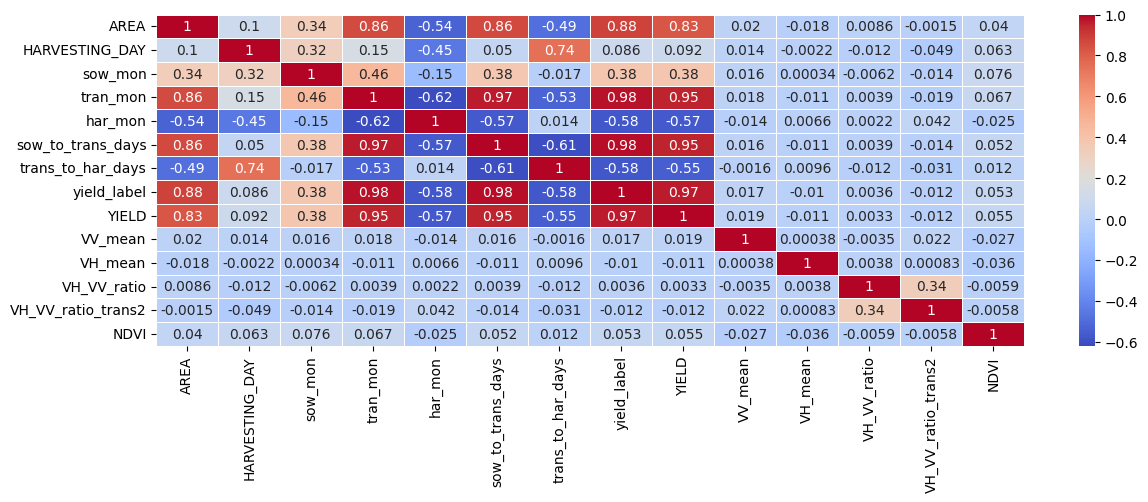

In [14]:
input_features = ["AREA", "HARVESTING_DAY", "sow_mon", "tran_mon", "har_mon", "sow_to_trans_days", "trans_to_har_days", "yield_label", "YIELD", "VV_mean", "VH_mean", "VH_VV_ratio", "VH_VV_ratio_trans2", "NDVI"]
corr_matrix=ml_tab[input_features].corr()
plt.figure(figsize=(14,4.3))
sns.heatmap(corr_matrix, linewidth=0.5, annot=True, cmap='coolwarm')

In [15]:
# from sklearn.preprocessing import StandardScaler
# from sklearn.linear_model import LogisticRegression
# from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# input_features = ["sow_to_trans_days"]
# X = ml_tab[input_features].values  

# y = (ml_tab['YIELD'] > 0).astype(int).values  

# train_mask = ml_tab['SPLIT'] == 1  
# test_mask = ml_tab['SPLIT'] == 0  

# X_train, X_test = X[train_mask], X[test_mask]
# y_train_class, y_test_class = y[train_mask], y[test_mask]

# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)

# c1 = LogisticRegression()
# c1.fit(X_train_scaled, y_train_class)

# y_pred_class = c1.predict(X_test_scaled)

# accuracy = accuracy_score(y_test_class, y_pred_class)
# conf_matrix = confusion_matrix(y_test_class, y_pred_class)
# report = classification_report(y_test_class, y_pred_class)

# print(f"✅ Accuracy: {accuracy:.2f}")
# print("\n🔹 Confusion Matrix:\n", conf_matrix)
# print("\n🔹 Classification Report:\n", report)


In [16]:
ml_tab.groupby(['YIELD', 'SPLIT']).size().reset_index()

,YIELD,SPLIT,0
0,0.0,0,1331
1,0.0,1,8684
2,800.0,0,8
3,800.0,1,8
4,820.0,0,8
...,...,...,...
83,2600.0,1,8
84,2640.0,0,8
85,2640.0,1,40
86,3600.0,1,22


In [17]:
# def test_predict(npz_file_path, custom_cnn, reg_lgb):
    
#     other_inputs = np.array([-1]) 
#     final_array = np.expand_dims(other_inputs, axis=0) 

#     prediction = reg_lgb.predict(final_array) 

#     return prediction[0]  


In [18]:
# test_file_path = "/kaggle/input/paddydataset/Paddy_Dataset_L8/114/LC08_142053_20190110.npz"

# predicted_value = test_predict(test_file_path, custom_cnn, c1)


In [19]:
# print("Predicted Yield:", predicted_value)

# actual_yield = ml_tab.loc[
#     (ml_tab["UNIQUE_ID"] == 114) & (ml_tab["file"] == "LC08_142053_20190110.npz"),
#     "yield_label"
# ]

# print("Actual Yield:", actual_yield.values if not actual_yield.empty else "Not Found")


In [20]:
# print(X_train.shape)
# print(type(y_train_class))
# # X_train['features']
# X
# X_features
# X[0]

In [21]:
ml_tab_1 = ml_tab[ml_tab["YIELD"]>0]

In [22]:
ml_tab_1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4423 entries, 54 to 14426
Data columns (total 27 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   UNIQUE_ID           4423 non-null   int64  
 1   file                4423 non-null   object 
 2   AREA                4423 non-null   float64
 3   HARVESTING_DAY      4423 non-null   int64  
 4   YIELD               4423 non-null   float64
 5   SPLIT               4423 non-null   int64  
 6   sow_mon             4423 non-null   int64  
 7   tran_mon            4423 non-null   int64  
 8   har_mon             4423 non-null   int64  
 9   start_mon           4423 non-null   int64  
 10  end_mon             4423 non-null   int64  
 11  sow_period          4423 non-null   int64  
 12  sow_to_trans_days   4423 non-null   int64  
 13  trans_to_har_days   4423 non-null   int64  
 14  x_img               4423 non-null   object 
 15  file_check          4423 non-null   object 
 16  NDVI     

In [23]:
ml_tab_1["YIELD"].value_counts()

YIELD
1800.00    608
1920.00    593
2040.00    346
2160.00    226
1680.00    195
          ... 
1930.00      8
850.00       8
840.00       8
1266.67      8
2600.00      8
Name: count, Length: 65, dtype: int64

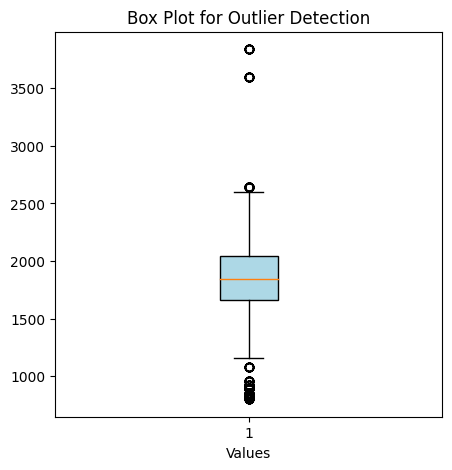

-0.47142512264653935

In [24]:
plt.figure(figsize=(5, 5))
plt.boxplot(ml_tab_1['YIELD'], patch_artist=True, boxprops=dict(facecolor="lightblue"))
plt.xlabel('Values')
plt.title('Box Plot for Outlier Detection')
plt.show()
ml_tab_1["AREA"].skew()

In [25]:
Q1 = ml_tab_1['YIELD'].quantile(0.25)  
Q3 = ml_tab_1['YIELD'].quantile(0.75)  
IQR = Q3 - Q1 

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = ml_tab_1[(ml_tab_1['YIELD'] < lower_bound) | (ml_tab_1['YIELD'] > upper_bound)]
outliers["YIELD"]

1898      900.0
1899      900.0
1900      900.0
1901      900.0
1902      900.0
          ...  
14373    2640.0
14374    2640.0
14375    2640.0
14376    2640.0
14377    2640.0
Name: YIELD, Length: 274, dtype: float64

In [26]:
Q1 = ml_tab_1['sow_to_trans_days'].quantile(0.25)  
Q3 = ml_tab_1['sow_to_trans_days'].quantile(0.75)  
IQR = Q3 - Q1 

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = ml_tab_1[(ml_tab_1['sow_to_trans_days'] < lower_bound) | (ml_tab_1['sow_to_trans_days'] > upper_bound)]
outliers["sow_to_trans_days"]

54       34
55       34
56       34
57       34
58       34
         ..
14338    29
14339    29
14340    29
14341    29
14342    29
Name: sow_to_trans_days, Length: 1241, dtype: int64

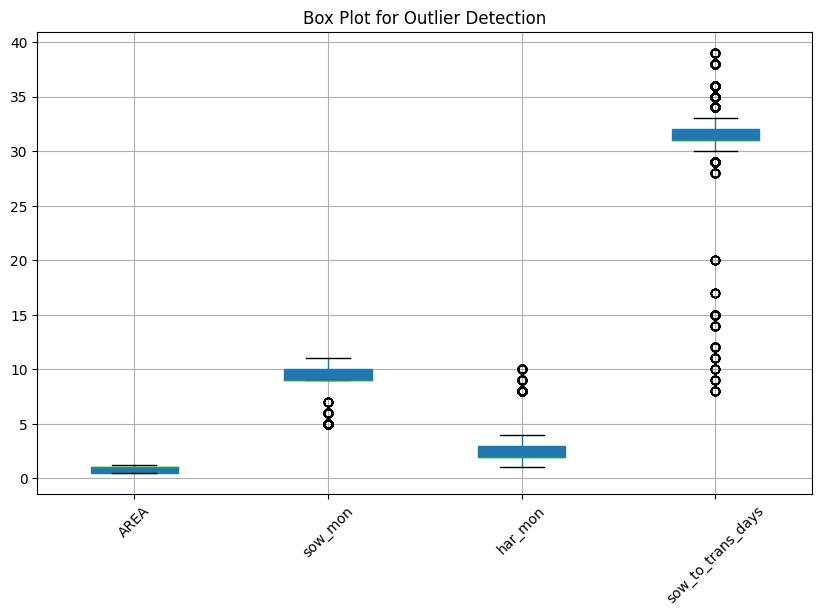

In [27]:
ml_tab_1[["AREA", "sow_mon", "har_mon", "sow_to_trans_days"]].boxplot(figsize=(10, 6), patch_artist=True)

plt.xticks(rotation=45)  # Rotate x-axis labels
plt.title("Box Plot for Outlier Detection")
plt.show()


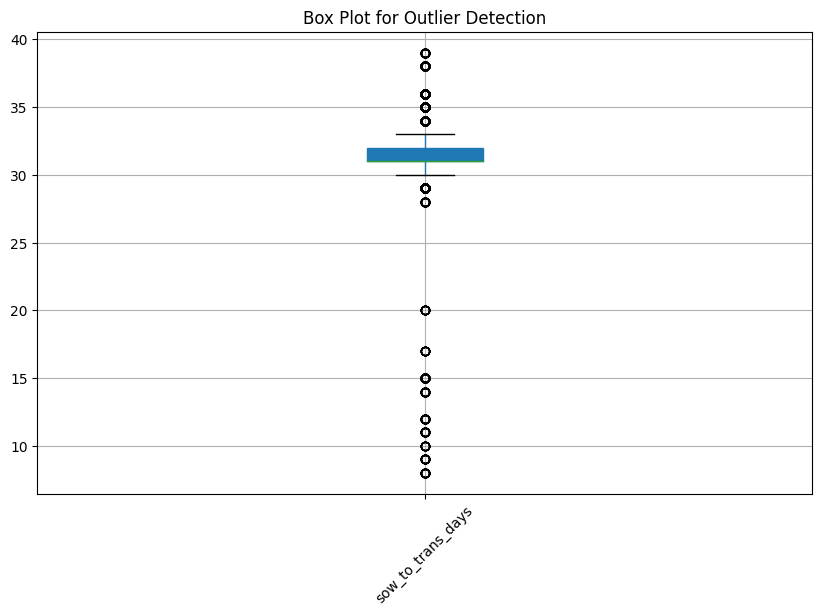

In [28]:
ml_tab_1[["sow_to_trans_days"]].boxplot(figsize=(10, 6), patch_artist=True)

plt.xticks(rotation=45)  # Rotate x-axis labels
plt.title("Box Plot for Outlier Detection")
plt.show()


In [29]:
# ml_tab_1.loc[:, 'sow_to_trans_days'] = np.log1p(ml_tab_1['sow_to_trans_days']).astype(np.float64)
# # ml_tab_1.loc[:, 'YIELD'] = np.log1p(ml_tab_1['YIELD'])
ml_tab_1.loc[:, 'sow_to_trans_days'] = np.log1p(ml_tab_1['sow_to_trans_days']).astype(np.float64)
ml_tab_1.loc[:, 'YIELD'] = np.log1p(ml_tab_1['YIELD'])

<ipython-input-29-8c8d45c496cd>:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[3.55534806 3.55534806 3.55534806 ... 3.49650756 3.49650756 3.49650756]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  ml_tab_1.loc[:, 'sow_to_trans_days'] = np.log1p(ml_tab_1['sow_to_trans_days']).astype(np.float64)


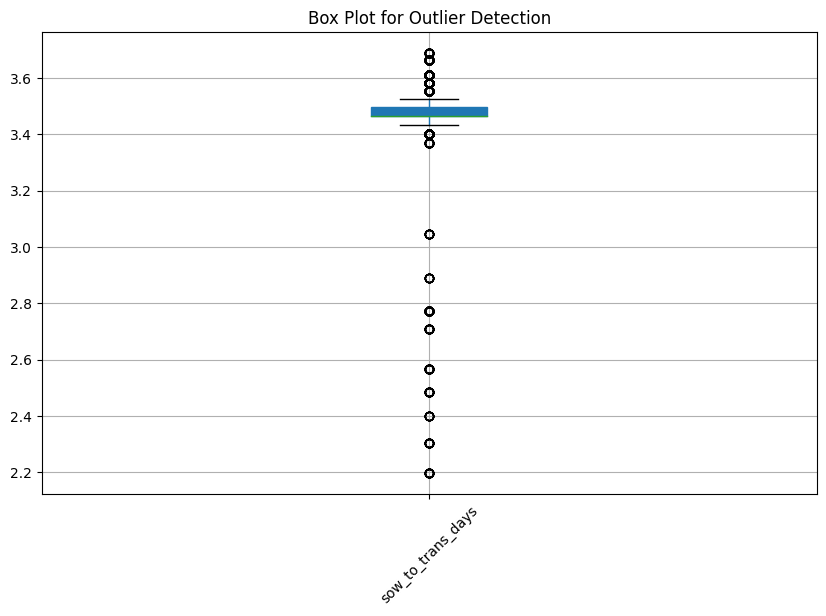

In [30]:
ml_tab_1[["sow_to_trans_days"]].boxplot(figsize=(10, 6), patch_artist=True)

plt.xticks(rotation=45)  # Rotate x-axis labels
plt.title("Box Plot for Outlier Detection")
plt.show()


In [90]:
# type(final_cnn_features)

In [91]:
print(X_tabular.shape)        # should be (4423, 5)
# print(final_cnn_features.shape)


(4423, 10)


In [53]:
ml_tab['x_cnn_features']

0        [0.         0.         0.         0.         0...
1        [0.         0.         0.         0.         0...
2        [0.         0.         0.         0.         0...
3        [0.         0.         0.         0.         0...
4        [0.         0.         0.         0.         0...
                               ...                        
14433    [0.         0.         0.         0.         0...
14434    [0.         0.         0.         0.         0...
14435    [0.         0.         0.         0.         0...
14436    [0.         0.         0.         0.         0...
14437    [0.         0.         0.         0.         0...
Name: x_cnn_features, Length: 14438, dtype: object

In [69]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# from collections import Counter
# from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# from sklearn.model_selection import KFold
# import lightgbm as lgb

# input_features = ["AREA", "sow_mon", "har_mon", "sow_to_trans_days", "trans_to_har_days", "VV_mean", "VH_mean", "VH_VV_ratio", "VH_VV_ratio_trans2", "NDVI"]

# X_tabular = ml_tab_1[input_features].values
# # ml_tab_1["x_cnn_features"].apply(lambda x: np.array(eval(x)) if isinstance(x, str) else np.array(x)).values
# # )

# # X_features = np.stack(ml_tab['x_cnn_features'].apply(eval).values)

# X_features = np.vstack(ml_tab_1["x_cnn_features"].apply(lambda x: np.array(eval(x)) if isinstance(x, str) else np.array(x)).values)

# X = np.hstack([X_tabular, X_features])  

# y = ml_tab_1['YIELD'].values

# yield_counts = Counter(y)  
# total_samples = len(y)
# weights = {k: total_samples / (len(yield_counts) * v) for k, v in yield_counts.items()}  
# weights_array = np.array([weights[val] for val in y])  

# train_mask = ml_tab_1['SPLIT'] == 1
# test_mask = ml_tab_1['SPLIT'] == 0
# X_train, X_test = X[train_mask], X[test_mask]
# y_train, y_test = y[train_mask], y[test_mask]
# weights_train = weights_array[train_mask]


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold
import lightgbm as lgb

# --- Define input features (tabular part) ---
input_features = [
    "AREA", "sow_mon", "har_mon",
    "sow_to_trans_days", "trans_to_har_days",
    "VV_mean", "VH_mean", "VH_VV_ratio",
    "VH_VV_ratio_trans2", "NDVI"
]

# --- Extract tabular data ---
X_tabular = ml_tab_1[input_features].values

# --- Parse CNN features safely ---
def parse_cnn_feature(x):
    """
    Convert string or list-like CNN feature representation into a numeric numpy array.
    Handles malformed strings with missing commas or newlines.
    """
    if isinstance(x, str):
        x = x.replace('[', '').replace(']', '').replace('\n', ' ')
        return np.fromstring(x, sep=' ')
    elif isinstance(x, (list, np.ndarray)):
        return np.array(x)
    else:
        return np.zeros(128)  # fallback if something unexpected

X_cnn = np.vstack(ml_tab_1["x_cnn_features"].apply(parse_cnn_feature).values)

print("✅ CNN features parsed successfully.")
print("CNN feature shape:", X_cnn.shape)

# --- Combine tabular + CNN features ---
X = np.hstack([X_tabular, X_cnn])
y = ml_tab_1["YIELD"].values

# --- Compute sample weights (optional) ---
yield_counts = Counter(y)
total_samples = len(y)
weights = {k: total_samples / (len(yield_counts) * v) for k, v in yield_counts.items()}
weights_array = np.array([weights[val] for val in y])

# --- Train/Test Split ---
train_mask = ml_tab_1["SPLIT"] == 1
test_mask  = ml_tab_1["SPLIT"] == 0

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]
weights_train   = weights_array[train_mask]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


✅ CNN features parsed successfully.
CNN feature shape: (4423, 128)
Train shape: (3968, 138)
Test shape: (455, 138)


In [70]:
X_tabular.shape, X_features.shape

((4423, 10), (4423, 1))

In [71]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

rf1 = RandomForestRegressor(
    n_estimators=126, 
    max_depth=4, 
    min_samples_split=5,
    min_samples_leaf=6,
    random_state=42, 
    n_jobs=-1
)

rf1.fit(X_train, y_train)  

y_test_pred_rf1 = rf1.predict(X_test)
y_train_pred_rf1 = rf1.predict(X_train)

rf1_mae = mean_absolute_error(y_test, y_test_pred_rf1)
rf1_rmse = mean_squared_error(y_test, y_test_pred_rf1, squared=False)

r2_train = r2_score(y_train, y_train_pred_rf1)
r2_test = r2_score(y_test, y_test_pred_rf1)


In [72]:
diff =abs(y_test - y_test_pred_rf1)

print("Mean Difference:", diff.mean())
print("sum Deviation:", diff.sum())
print("Max Difference:", diff.max())
print("Min Difference:", diff.min())

Mean Difference: 0.1829913106695041
sum Deviation: 83.26104635462437
Max Difference: 0.7197879889397498
Min Difference: 0.002830419936131534


In [73]:
print("Mean Absolute Error (MAE):", rf1_mae)
print("Root Mean Squared Error (RMSE):", rf1_rmse)
print("Test R² Score:", r2_test)
print("Train R² Score:", r2_train)
print("Difference: ", r2_train - r2_test)


Mean Absolute Error (MAE): 0.1829913106695041
Root Mean Squared Error (RMSE): 0.24566502536708695
Test R² Score: 0.31225600686359956
Train R² Score: 0.39090133623259915
Difference:  0.0786453293689996


In [74]:
# from lightgbm import early_stopping
# kf = KFold(n_splits=5, shuffle=True, random_state=42)

# lgb1_train_r2, lgb1_val_r2 = [], []
# lgb1_train_rmse, lgb1_val_rmse = [], []

# # lgb_params = {
# #     'n_estimators': 550,
# #     'learning_rate': 0.011125939592574711,
# #     'max_depth': 5,
# #     'num_leaves': 32,
# #     'subsample': 0.6972031841860239,
# #     'colsample_bytree': 0.5287497460758034,
# #     'reg_lambda': 0.08330442459713975,
# #     'reg_alpha': 1.8520435401467105,
# #     'min_child_weight': 55,
# #     'random_state': 42
# # }
# # lgb_params = {
# #     'n_estimators': 550,
# #     'learning_rate': 0.01,  # Small decrease for better generalization
# #     'max_depth': 4,  # Reduced depth to prevent overfitting
# #     'num_leaves': 20,  # Less complexity
# #     'subsample': 0.7,  # Keep same, good balance
# #     'colsample_bytree': 0.5,  # Keep same
# #     'reg_lambda': 0.1,  # Slightly increased for better regularization
# #     'reg_alpha': 2.0,  # Increase L1 regularization to force sparsity
# #     'min_child_weight': 100,  # Avoid overfitting to small samples
# #     'random_state': 42
# # }
# lgb_params = {
#     'n_estimators': 500,
#     'learning_rate': 0.007,
#     'max_depth': 4,
#     'num_leaves': 20,
#     'subsample': 0.6,
#     'colsample_bytree': 0.5,
#     'reg_lambda': 0.4,  # Increased L2 regularization
#     'reg_alpha': 5.0,  # Increased L1 regularization
#     'min_child_weight': 140,  # Avoid overfitting 
#     'random_state': 42
# }

# for train_idx, val_idx in kf.split(X_train):
#     X_train_fold, X_val_fold = X_train[train_idx], X_train[val_idx]
#     y_train_fold, y_val_fold = y_train[train_idx], y_train[val_idx]
#     weights_train_fold = weights_train[train_idx]

#     lgb1 = lgb.LGBMRegressor(**lgb_params)
#     lgb1.fit(
#         X_train_fold, y_train_fold, sample_weight=weights_train_fold,
#         eval_set=[(X_val_fold, y_val_fold)], eval_metric='rmse',
#         callbacks=[early_stopping(50, verbose=True)]
#     )

#     y_train_pred_lgb1 = lgb1.predict(X_train_fold)
#     y_val_pred_lgb1 = lgb1.predict(X_val_fold)

#     lgb1_train_r2.append(r2_score(y_train_fold, y_train_pred_lgb1))
#     lgb1_val_r2.append(r2_score(y_val_fold, y_val_pred_lgb1))

#     lgb1_train_rmse.append(np.sqrt(mean_squared_error(y_train_fold, y_train_pred_lgb1)))
#     lgb1_val_rmse.append(np.sqrt(mean_squared_error(y_val_fold, y_val_pred_lgb1)))

# final_model_lgb1 = lgb.LGBMRegressor(**lgb_params)
# final_model_lgb1.fit(X_train, y_train, sample_weight=weights_train)


In [75]:
from lightgbm import early_stopping
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import KFold
import matplotlib.pyplot as plt
import numpy as np

kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Metric lists
lgb1_train_r2, lgb1_val_r2 = [], []
lgb1_train_rmse, lgb1_val_rmse = [], []

# Collect validation data for ALL folds
all_y_val, all_y_val_pred = [], []

# LightGBM Parameters
lgb_params = {
    'n_estimators': 500,
    'learning_rate': 0.009,
    'max_depth': 5,
    'num_leaves': 20,
    'subsample': 0.6,
    'colsample_bytree': 0.5,
    'reg_lambda': 0.6,
    'reg_alpha': 5.3,
    'min_child_weight': 140,
    'random_state': 42
}



# K-Fold Loop
for train_idx, val_idx in kf.split(X_train):
    X_train_fold, X_val_fold = X_train[train_idx], X_train[val_idx]
    y_train_fold, y_val_fold = y_train[train_idx], y_train[val_idx]
    weights_train_fold = weights_train[train_idx]

    lgb1 = lgb.LGBMRegressor(**lgb_params)
    lgb1.fit(
        X_train_fold, y_train_fold,
        eval_set=[(X_val_fold, y_val_fold)], eval_metric='rmse',
        callbacks=[early_stopping(50, verbose=True)]
    )

    y_train_pred = lgb1.predict(X_train_fold)
    y_val_pred = lgb1.predict(X_val_fold)

    # Save fold scores
    lgb1_train_r2.append(r2_score(y_train_fold, y_train_pred))
    lgb1_val_r2.append(r2_score(y_val_fold, y_val_pred))
    lgb1_train_rmse.append(np.sqrt(mean_squared_error(y_train_fold, y_train_pred)))
    lgb1_val_rmse.append(np.sqrt(mean_squared_error(y_val_fold, y_val_pred)))

    # Store validation results for scatter plot
    all_y_val.extend(y_val_fold)
    all_y_val_pred.extend(y_val_pred)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001920 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3998
[LightGBM] [Info] Number of data points in the train set: 3174, number of used features: 23
[LightGBM] [Info] Start training from score 7.496130
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM

Splitting your training data into 5 folds for cross-validation<br>
✔️ Training 5 LightGBM models, each time tracking performance<br>
✔️ Using strong regularization to avoid overfitting<br>
✔️ Warnings indicate the model avoids weak splits (could be due to small dataset or strong regularization)<br>
✔️ Finally, training the model on the full dataset<br>
✔️ Ready to test the model on unseen data<br>

   feature  importance
4       f4        1723
3       f3         694
0       f0         360
6       f6         248
1       f1         245
5       f5         242
2       f2         240
67     f67         220
7       f7         196
9       f9         184
96     f96         162
50     f50         162
8       f8         132
23     f23          52
20     f20          43
69     f69          10
68     f68           6
31     f31           5
52     f52           5
10     f10           2


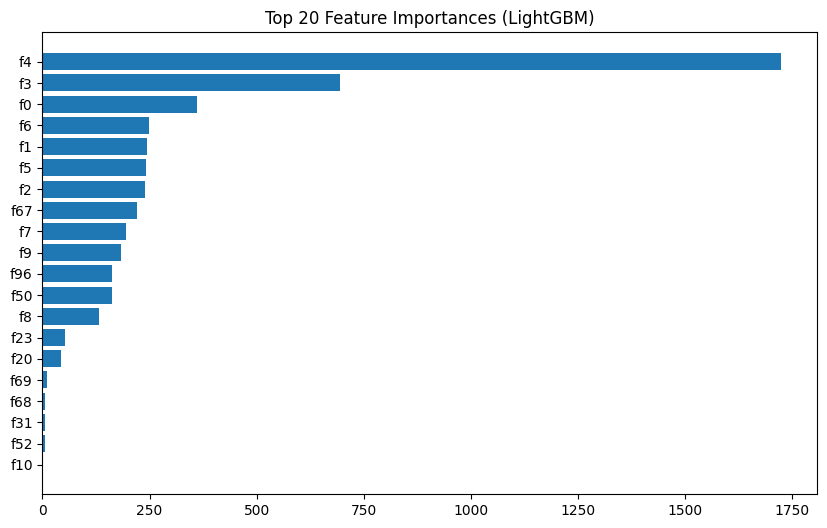

In [76]:
n_features = X_train.shape[1]

# If your input_features list matches this length, use it.
# Otherwise, auto-generate generic names
if len(input_features) == n_features:
    feature_names = input_features
else:
    feature_names = [f"f{i}" for i in range(n_features)]  # fallback

feature_importances = pd.DataFrame({
    "feature": feature_names,
    "importance": lgb1.feature_importances_
}).sort_values(by="importance", ascending=False)

print(feature_importances.head(20))

# Plot
plt.figure(figsize=(10,6))
plt.barh(feature_importances["feature"][:20], feature_importances["importance"][:20])
plt.gca().invert_yaxis()
plt.title("Top 20 Feature Importances (LightGBM)")
plt.show()

# ["AREA", "sow_mon", "har_mon", "sow_to_trans_days", "trans_to_har_days", 
#  "VV_mean", "VH_mean", "VH_VV_ratio", "VH_VV_ratio_trans2", "NDVI"]
# f0 → AREA

# f1 → sow_mon

# f2 → har_mon

# f3 → sow_to_trans_days

# f4 → trans_to_har_days

# f5 → VV_mean

# f6 → VH_mean

# f7 → VH_VV_ratio

# f8 → VH_VV_ratio_trans2

# f9 → NDVI

# f10 … fN → CNN features

Your importance table, remapped

f4 (1711) → trans_to_har_days (very strong)

f3 (691) → sow_to_trans_days

f0 (364) → AREA

f6 (258) → VH_mean (SAR)

f1 (250) → sow_mon

f2 (238) → har_mon

f5 (236) → VV_mean (SAR)

f67 (225) → CNN feature

f7 (195) → VH_VV_ratio (SAR)

f9 (189) → NDVI

f96 (165) → CNN feature

f50 (160) → CNN feature

f8 (129) → VH_VV_ratio_trans2 (SAR)

others (f23, f20, …) = weaker CNN features

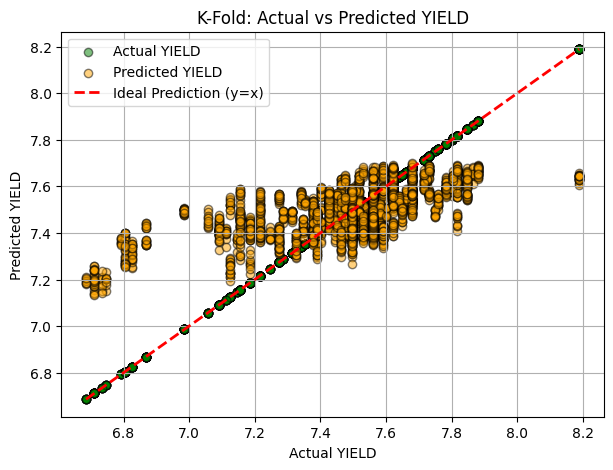

Mean Train R²: 0.4151
Mean Validation R²: 0.3853
Mean Train RMSE: 0.1694
Mean Validation RMSE: 0.1736
R² Gap (Train - Val): 0.029858528813738183


In [77]:
# Plot 1: Actual vs Predicted YIELD (ALL FOLDS)
plt.figure(figsize=(7, 5))
plt.scatter(all_y_val, all_y_val, color="green", alpha=0.5, edgecolor="black", label="Actual YIELD")
plt.scatter(all_y_val, all_y_val_pred, color="orange", alpha=0.5, edgecolor="black", label="Predicted YIELD")

min_val, max_val = min(min(all_y_val), min(all_y_val_pred)), max(max(all_y_val), max(all_y_val_pred))
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label="Ideal Prediction (y=x)")

plt.xlabel("Actual YIELD")
plt.ylabel("Predicted YIELD")
plt.title("K-Fold: Actual vs Predicted YIELD")
plt.legend()
plt.grid(True)
plt.show()

# Print K-Fold Averages
print(f"Mean Train R²: {np.mean(lgb1_train_r2):.4f}")
print(f"Mean Validation R²: {np.mean(lgb1_val_r2):.4f}")
print(f"Mean Train RMSE: {np.mean(lgb1_train_rmse):.4f}")
print(f"Mean Validation RMSE: {np.mean(lgb1_val_rmse):.4f}")
print("R² Gap (Train - Val):", np.mean(lgb1_train_r2) - np.mean(lgb1_val_r2))


MEAN Train R²: 0.4151 (Val R²: 0.3853)
Train RMSE: 0.1694 (Val RMSE: 0.1736)
Difference:  0.029858528813738183


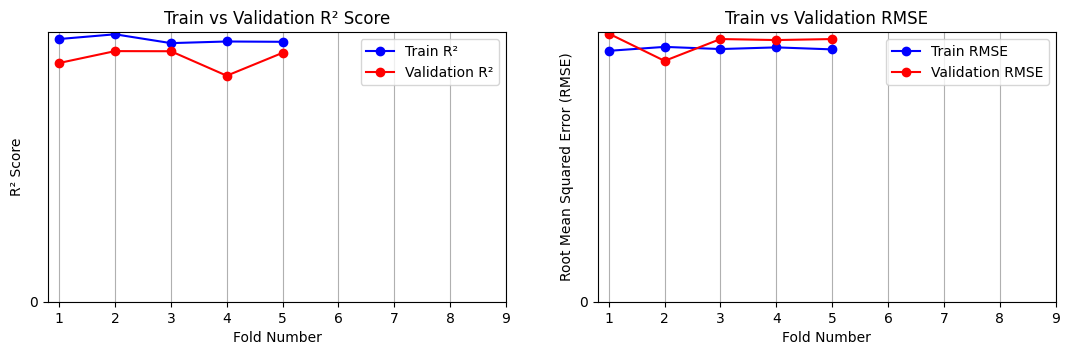

In [78]:
print(f"MEAN Train R²: {np.mean(lgb1_train_r2):.4f} (Val R²: {np.mean(lgb1_val_r2):.4f})")
print(f"Train RMSE: {np.mean(lgb1_train_rmse):.4f} (Val RMSE: {np.mean(lgb1_val_rmse):.4f})")
print("Difference: ", (np.mean(lgb1_train_r2) - np.mean(lgb1_val_r2)))

plt.figure(figsize=(13, 3.5))
plt.subplot(1, 2, 1)
plt.plot(range(1, kf.get_n_splits() + 1), lgb1_train_r2, label="Train R²", marker='o', color='blue')
plt.plot(range(1, kf.get_n_splits() + 1), lgb1_val_r2, label="Validation R²", marker='o', color='red')
plt.xlabel("Fold Number")
plt.ylabel("R² Score")
plt.title("Train vs Validation R² Score")
plt.legend()
plt.grid()
plt.xticks(range(1, kf.get_n_splits() + 5, 1))
plt.yticks(range(0,1))

plt.subplot(1, 2, 2)
plt.plot(range(1, kf.get_n_splits() + 1), lgb1_train_rmse, label="Train RMSE", marker='o', color='blue')
plt.plot(range(1, kf.get_n_splits() + 1), lgb1_val_rmse, label="Validation RMSE", marker='o', color='red')
plt.xlabel("Fold Number")
plt.ylabel("Root Mean Squared Error (RMSE)")
plt.title("Train vs Validation RMSE")
plt.legend()
plt.grid()
plt.xticks(range(1, kf.get_n_splits() + 5, 1))
plt.yticks(range(0,1))
plt.show()


In [79]:
final_model_lgb1 = lgb.LGBMRegressor(**lgb_params)
final_model_lgb1.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000305 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4183
[LightGBM] [Info] Number of data points in the train set: 3968, number of used features: 23
[LightGBM] [Info] Start training from score 7.497520
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

LGBMRegressor(colsample_bytree=0.5, learning_rate=0.009, max_depth=5,
              min_child_weight=140, n_estimators=500, num_leaves=20,
              random_state=42, reg_alpha=5.3, reg_lambda=0.6, subsample=0.6)

* In K-Fold CV, keeping everything in log-space is acceptable and consistent.
* But for final evaluation and real-world interpretation, inverse-transform is necessary.

In [81]:
import joblib

# Save
joblib.dump(final_model_lgb1, "lgbm_yield_model.pkl")


['lgbm_yield_model.pkl']

In [82]:
from sklearn.metrics import mean_absolute_percentage_error
y_train_pred_lgb1 = np.expm1(final_model_lgb1.predict(X_train)) 
y_test_pred_lgb1 = np.expm1(final_model_lgb1.predict(X_test))

final_train_r2 = r2_score(y_train, final_model_lgb1.predict(X_train)) 
final_test_r2 = r2_score(y_test, final_model_lgb1.predict(X_test)) 

final_train_rmse = np.sqrt(mean_squared_error(np.expm1(y_train), np.expm1(final_model_lgb1.predict(X_train))))
final_test_rmse = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(final_model_lgb1.predict(X_test))))

print(f"Final Train R² Score: {final_train_r2:.4f}")
print(f"Final Test R² Score: {final_test_r2:.4f}")
print(f"Final Train RMSE: {final_train_rmse:.4f}")
print(f"Final Test RMSE: {final_test_rmse:.4f}")

# Compute MAPE using the inverse-transformed values
mape_train = mean_absolute_percentage_error(np.expm1(y_train), y_train_pred_lgb1) * 100
mape_test = mean_absolute_percentage_error(np.expm1(y_test), y_test_pred_lgb1) * 100

print(f"Final Train MAPE: {mape_train:.2f}%")
print(f"Final Test MAPE: {mape_test:.2f}%")



Final Train R² Score: 0.4389
Final Test R² Score: 0.4193
Final Train RMSE: 284.3089
Final Test RMSE: 475.8462
Final Train MAPE: 12.86%
Final Test MAPE: 15.91%


In [83]:
# --- Absolute Differences ---
kdiff = np.abs(np.array(all_y_val) - np.array(all_y_val_pred))

# If you want to compare with test predictions (assuming you have them)
diff = np.abs(y_test - y_test_pred_lgb1) 

# --- Difference Summary ---
print("K-Fold Validation Sum of Differences:", kdiff.sum())
print("Test Set Sum of Differences:", diff.sum())
print("Test Set Mean Difference:", diff.mean())
print("Test Set Max Difference:", diff.max())
print("Test Set Min Difference:", diff.min())

K-Fold Validation Sum of Differences: 509.800251679774
Test Set Sum of Differences: 797402.3239161613
Test Set Mean Difference: 1752.5325800355195
Test Set Max Difference: 2172.8954868888627
Test Set Min Difference: 1221.3668535608267


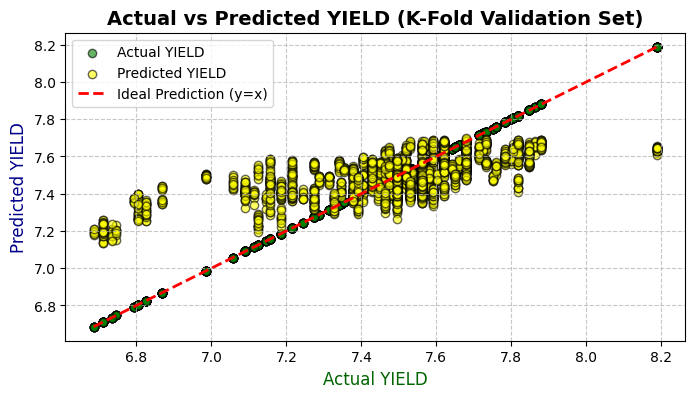

In [84]:
# --- Scatter Plot for K-Fold Validation (All folds combined) ---
plt.figure(figsize=(8, 4))

plt.scatter(all_y_val, all_y_val, color="green", alpha=0.6, edgecolor="black", label="Actual YIELD")
plt.scatter(all_y_val, all_y_val_pred, color="yellow", alpha=0.6, edgecolor="black", label="Predicted YIELD")

min_val = min(min(all_y_val), min(all_y_val_pred))
max_val = max(max(all_y_val), max(all_y_val_pred))
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label="Ideal Prediction (y=x)")

plt.xlabel("Actual YIELD", fontsize=12, color="darkgreen")
plt.ylabel("Predicted YIELD", fontsize=12, color="darkblue")
plt.title("Actual vs Predicted YIELD (K-Fold Validation Set)", fontsize=14, fontweight="bold")

plt.legend()
plt.grid(True, linestyle="--", alpha=0.7)

plt.show()


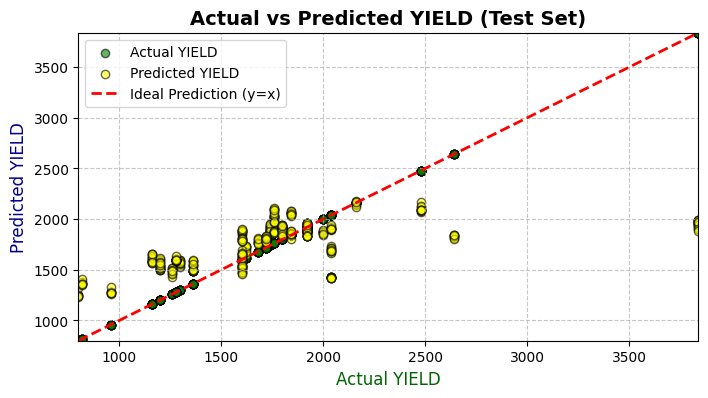

In [85]:
plt.figure(figsize=(8, 4))

# Inverse-transform from log scale to original YIELD scale
y_test_orig = np.expm1(y_test)
y_test_pred_orig = np.expm1(final_model_lgb1.predict(X_test))

# Scatter plots
plt.scatter(y_test_orig, y_test_orig, color="green", alpha=0.6, edgecolor="black", label="Actual YIELD")
plt.scatter(y_test_orig, y_test_pred_orig, color="yellow", alpha=0.6, edgecolor="black", label="Predicted YIELD")

# Ideal y = x line
min_test = min(y_test_orig.min(), y_test_pred_orig.min())
max_test = max(y_test_orig.max(), y_test_pred_orig.max())
plt.plot([min_test, max_test], [min_test, max_test], 'r--', linewidth=2, label="Ideal Prediction (y=x)")

# Labels and title
plt.xlabel("Actual YIELD", fontsize=12, color="darkgreen")
plt.ylabel("Predicted YIELD", fontsize=12, color="darkblue")
plt.title("Actual vs Predicted YIELD (Test Set)", fontsize=14, fontweight="bold")

# Axis range in original scale
plt.xlim(min_test, max_test)
plt.ylim(min_test, max_test)

plt.legend()
plt.grid(True, linestyle="--", alpha=0.7)
plt.show()



In [86]:
def test_predict(npz_file_path, custom_cnn, model):

    data = np.load(npz_file_path)  

    bands = ['SR_B4', 'SR_B5', 'SR_B6', 'ST_B10', 'ST_TRAD']
    X_test_img = np.stack([data[band] for band in bands], axis=-1)  

    X_test_img = np.expand_dims(X_test_img, axis=0) 

    other_inputs = np.array([1.0, 10, 3, 31, 133])  
    other_inputs = np.expand_dims(other_inputs, axis=0)  

    feature_extractor = Model(inputs=custom_cnn.input, outputs=custom_cnn.output)

    features = feature_extractor.predict(X_test_img)  
    features = features.reshape(1, -1) 

    final_array = np.hstack((features, other_inputs))  

    prediction = model.predict(final_array)  

    return prediction[0] 


In [87]:
ml_tab_1[(ml_tab_1["file"]=="LC08_143053_20200205.npz") & (ml_tab_1["UNIQUE_ID"]==2062)]

,UNIQUE_ID,file,AREA,HARVESTING_DAY,YIELD,SPLIT,sow_mon,tran_mon,har_mon,start_mon,...,obs_date,trans_YIELD,std_YIELD,x_cnn_features,year_month,VV_mean,VH_mean,VH_VV_ratio,VH_VV_ratio_trans2,yield_label
6623,2062,LC08_143053_20200205.npz,1.0,167,6.867974,1,10,11,3,10,...,2020-02-05,1.462405,1.462405,[0. 0. 0. 0. 0...,2020-02,-2.787925e-07,-1.869950e-07,68.044288,2.483619,1


In [88]:
input_features = ["AREA", "sow_mon", "har_mon", "sow_to_trans_days", "trans_to_har_days"]

In [89]:
test_file_path = "/kaggle/input/paddydataset/Paddy_Dataset_L8/2062/LC08_143053_20200205.npz"

predicted_value = test_predict(test_file_path, custom_cnn, final_model_lgb1)
real_yield = np.expm1(predicted_value)

print("Predicted Yield:", real_yield)


NameError: name 'custom_cnn' is not defined

In [ ]:
# bands = ['SR_B4', 'SR_B5', 'SR_B6', 'ST_B10', 'ST_TRAD']
#     data = np.load("/kaggle/input/paddydataset/Paddy_Dataset_L8/1062/LC08_142053_20180819.npz")  
# other_inputs = [0.07, 9, 12,-1, 153]

In [ ]:
# # Final predictions on train and test set
# y_train_pred_lgb1 = final_model_lgb1.predict(X_train)
# y_test_pred_lgb1 = final_model_lgb1.predict(X_test)

# # Compute final Train & Test R² scores
# final_train_r2 = r2_score(y_train, y_train_pred_lgb1)
# final_test_r2 = r2_score(y_test, y_test_pred_lgb1)

# # Compute final Train & Test RMSE
# final_train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred_lgb1))
# final_test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_lgb1))

# # Print results
# print(f"Final Train R² Score: {final_train_r2:.4f}")
# print(f"Final Test R² Score: {final_test_r2:.4f}")
# print(f"Final Train RMSE: {final_train_rmse:.4f}")
# print(f"Final Test RMSE: {final_test_rmse:.4f}")


In [ ]:
# import lightgbm as lgb
# # KFold Cross-Validation
# kf = KFold(n_splits=10, shuffle=True, random_state=42)

# lgb2_train_r2, lgb2_val_r2 = [], []
# lgb2_train_rmse, lgb2_val_rmse = [], []

# lgb_params = {
#     'n_estimators': 286,
#     'learning_rate': 0.011,
#     'max_depth': 5,
#     'num_leaves': 16,
#     'subsample': 0.8,
#     'colsample_bytree': 0.63,
#     'reg_lambda': 0.05,
#     'reg_alpha': 1.5,
#     'random_state': 42
# }

# for train_idx, val_idx in kf.split(X_train):
#     X_train_fold, X_val_fold = X_train[train_idx], X_train[val_idx]
#     y_train_fold, y_val_fold = y_train[train_idx], y_train[val_idx]
#     weights_train_fold = weights_train[train_idx]

#     # Train LGBM model
#     lgb2 = lgb.LGBMRegressor(**lgb_params)
#     lgb2.fit(X_train_fold, y_train_fold, sample_weight=weights_train_fold)

#     # Predictions
#     y_train_pred = lgb2.predict(X_train_fold)
#     y_val_pred = lgb2.predict(X_val_fold)

#     # Compute Train & Validation R²
#     lgb2_train_r2.append(r2_score(y_train_fold, y_train_pred))
#     lgb2_val_r2.append(r2_score(y_val_fold, y_val_pred))

#     # Compute Train & Validation RMSE
#     lgb2_train_rmse.append(np.sqrt(mean_squared_error(y_train_fold, y_train_pred)))
#     lgb2_val_rmse.append(np.sqrt(mean_squared_error(y_val_fold, y_val_pred)))

# # Train final model on full train set
# final_model = lgb.LGBMRegressor(**lgb_params)
# final_model.fit(X_train, y_train, sample_weight=weights_train)
# y_test_pred_lgb2 = final_model.predict(X_test)

# # Compute Final Test Metrics
# lgb2_test_r2 = r2_score(y_test, y_test_pred_lgb2)
# lgb2_test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_lgb2))


In [ ]:
# # Difference Calculation
# diff_test = abs(y_test - y_test_pred_lgb2)
# print("Mean Difference (Test Set):", diff_test.mean())
# print("Sum Deviation (Test Set):", diff_test.sum())
# print("Max Difference (Test Set):", diff_test.max())
# print("Min Difference (Test Set):", diff_test.min())

# plt.figure(figsize=(8, 4))

# # Actual vs Predicted Scatter Plot (Test Set)
# plt.scatter(y_test, y_test, color="green", alpha=0.6, label="Actual YIELD", edgecolor="black")
# plt.scatter(y_test, y_test_pred_lgb2, color="yellow", alpha=0.6, label="Predicted YIELD", edgecolor="black")

# # Ideal Prediction Line (y = x)
# min_test_val = min(y_test.min(), y_test_pred_lgb2.min())  # ✅ FIXED
# max_test_val = max(y_test.max(), y_test_pred_lgb2.max())
# plt.plot([min_test_val, max_test_val], [min_test_val, max_test_val], 'r--', linewidth=2, label="Ideal Prediction (y=x)")

# # Labels and title
# plt.xlabel("Actual YIELD", fontsize=12, color="darkgreen")
# plt.ylabel("Predicted YIELD", fontsize=12, color="darkblue")
# plt.title("Actual vs Predicted YIELD (Test Set)", fontsize=14, fontweight="bold")

# # Legend and Grid
# plt.legend()
# plt.grid(True, linestyle="--", alpha=0.7)

# # Show plot
# plt.show()

In [ ]:
# plt.figure(figsize=(8, 4))

# # Actual vs Predicted Scatter Plot
# plt.scatter(y_val, y_val, color="green", alpha=0.6, label="Actual YIELD", edgecolor="black")
# plt.scatter(y_val, y_val_pred_lgb2, color="yellow", alpha=0.6, label="Predicted YIELD", edgecolor="black")

# # Ideal Prediction Line (y = x)
# min_val = min(y_val.min(), y_val_pred_lgb2.min())  # ✅ FIXED
# max_val = max(y_val.max(), y_val_pred_lgb2.max())
# plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label="Ideal Prediction (y=x)")

# # Labels and title
# plt.xlabel("Actual YIELD", fontsize=12, color="darkgreen")
# plt.ylabel("Predicted YIELD", fontsize=12, color="darkblue")
# plt.title("Actual vs Predicted YIELD (Validation Set)", fontsize=14, fontweight="bold")

# # Legend and Grid
# plt.legend()
# plt.grid(True, linestyle="--", alpha=0.7)

# # Show plot
# plt.show()

In [ ]:
# # Print Mean Train vs Test Scores
# print(f"MIN Train R²: {np.min(lgb2_train_r2):.4f} (MIN Test R²: {np.min(lgb2_test_r2):.4f})")
# print(f"MAX Train R²: {np.max(lgb2_train_r2):.4f} (MAX Test R²: {np.max(lgb2_test_r2):.4f})")
# print(f"MEAN Train R²: {np.mean(lgb2_train_r2):.4f} (Test R²: {np.mean(lgb2_test_r2):.4f})")
# print(f"Train RMSE: {np.mean(lgb2_train_rmse):.4f} (Test RMSE: {np.mean(lgb2_test_rmse):.4f})")
# print("Difference: ", (np.mean(lgb2_train_r2) - np.mean(lgb2_test_r2)))

# # Plot Train vs Test R² & RMSE
# plt.figure(figsize=(13, 3.5))

# # R² Score Plot
# plt.subplot(1, 2, 1)
# plt.plot(range(1, kf.get_n_splits() + 1), lgb2_train_r2, label="Train R²", marker='o', color='blue')

# # Ensure lgb2_test_r2 has the correct shape before plotting
# if len(lgb2_test_r2) == 1:  
#     plt.plot(range(1, kf.get_n_splits() + 1), np.repeat(lgb2_test_r2, kf.get_n_splits()), label="Test R²", marker='o', color='red')
# else:
#     plt.plot(range(1, kf.get_n_splits() + 1), lgb2_test_r2, label="Test R²", marker='o', color='red')

# plt.xlabel("Fold Number")
# plt.ylabel("R² Score")
# plt.title("Train vs Test R² Score")
# plt.legend()
# plt.grid()
# plt.xticks(range(1, kf.get_n_splits() + 1, 1))  
# plt.yticks(np.linspace(min(lgb2_train_r2 + lgb2_test_r2), max(lgb2_train_r2 + lgb2_test_r2), 5))

# # RMSE Plot
# plt.subplot(1, 2, 2)
# plt.plot(range(1, kf.get_n_splits() + 1), lgb2_train_rmse, label="Train RMSE", marker='o', color='blue')
# plt.plot(range(1, kf.get_n_splits() + 1), lgb2_test_rmse, label="Test RMSE", marker='o', color='red')

# plt.xlabel("Fold Number")
# plt.ylabel("Root Mean Squared Error (RMSE)")
# plt.title("Train vs Test RMSE")
# plt.legend()
# plt.grid()
# plt.xticks(range(1, kf.get_n_splits() + 1, 1))  
# plt.yticks(np.linspace(min(lgb2_train_rmse + lgb2_test_rmse), max(lgb2_train_rmse + lgb2_test_rmse), 5))

# plt.show()


In [ ]:
# from sklearn.model_selection import KFold
# from sklearn.metrics import r2_score, mean_squared_error
# import lightgbm as lgb
# import numpy as np

# # KFold Cross-Validation
# kf = KFold(n_splits=5, shuffle=True, random_state=42)

# rf2_train_r2, rf2_val_r2 = [], []
# rf2_train_rmse, rf2_val_rmse = [], []

# rf_params = {
#     'n_estimators': 500,
#     'max_depth': 6,
#     'min_samples_split': 4,
#     'min_samples_leaf': 5,
#     'random_state': 42,
#     'n_jobs': -1  # Use all cores
# }

# for train_idx, val_idx in kf.split(X_train):
#     X_train_fold, X_val_fold = X_train[train_idx], X_train[val_idx]
#     y_train_fold, y_val_fold = y_train[train_idx], y_train[val_idx]
#     weights_train_fold = weights_train[train_idx]

#     # Train Random Forest model
#     rf2 = RandomForestRegressor(**rf_params)
#     rf2.fit(X_train_fold, y_train_fold, sample_weight=weights_train_fold)

#     # Predictions
#     y_train_pred_rf2 = rf2.predict(X_train_fold)
#     y_val_pred_rf2 = rf2.predict(X_val_fold)

#     # Compute Train & Validation R²
#     rf2_train_r2.append(r2_score(y_train_fold, y_train_pred_rf2))
#     rf2_val_r2.append(r2_score(y_val_fold, y_val_pred_rf2))

#     # Compute Train & Validation RMSE
#     rf2_train_rmse.append(np.sqrt(mean_squared_error(y_train_fold, y_train_pred_rf2)))
#     rf2_val_rmse.append(np.sqrt(mean_squared_error(y_val_fold, y_val_pred_rf2)))

# # Train final model on full train set
# final_model = RandomForestRegressor(**rf_params)
# final_model.fit(X_train, y_train, sample_weight=weights_train)
# y_test_pred_rf2 = final_model.predict(X_test)

# # Compute Final Test Metrics
# test_r2 = r2_score(y_test, y_test_pred)
# test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
# print(f"Final Test R² Score: {test_r2:.4f}")
# print(f"Final Test RMSE: {test_rmse:.4f}")


In [ ]:
# kdiff = abs(y_val_fold - y_val_pred_rf2)
# diff = abs(y_test - y_test_pred_rf2)
# print("ksum:", kdiff.sum())
# print("Mean Difference:", diff.mean())
# print("sum:", diff.sum())
# print("Max Difference:", diff.max())
# print("Min Difference:", diff.min())

In [ ]:
# # Scatter Plot for Actual vs Predicted Values
# plt.figure(figsize=(8, 4))

# plt.scatter(y_val_fold, y_val_fold, color="green", alpha=0.6, edgecolor="black", label="Actual YIELD")
# plt.scatter(y_val_fold, y_val_pred_rf2, color="yellow", alpha=0.6, edgecolor="black", label="Predicted YIELD")

# # Ideal Prediction Line (y = x)
# min_val = min(y_val_fold.min(), y_val_pred_rf2.min())
# max_val = max(y_val_fold.max(), y_val_pred_rf2.max())
# plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label="Ideal Prediction (y=x)")

# # Labels and title
# plt.xlabel("Actual YIELD", fontsize=12, color="darkgreen")
# plt.ylabel("Predicted YIELD", fontsize=12, color="darkblue")
# plt.title("Actual vs Predicted YIELD (Validation Set)", fontsize=14, fontweight="bold")

# plt.legend()
# plt.grid(True, linestyle="--", alpha=0.7)
# plt.show()


In [ ]:
# # Scatter Plot for Actual vs Predicted Values
# plt.figure(figsize=(8, 4))

# plt.scatter(y_test, y_test, color="green", alpha=0.6, edgecolor="black", label="Actual YIELD")
# plt.scatter(y_test, y_test_pred_rf2, color="yellow", alpha=0.6, edgecolor="black", label="Predicted YIELD")

# # Ideal Prediction Line (y = x)
# min_val = min(y_test.min(), y_test_pred_rf2.min())
# max_val = max(y_test.max(), y_test_pred_rf2.max())
# plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label="Ideal Prediction (y=x)")

# # Labels and title
# plt.xlabel("Actual YIELD", fontsize=12, color="darkgreen")
# plt.ylabel("Predicted YIELD", fontsize=12, color="darkblue")
# plt.title("Actual vs Predicted YIELD (Validation Set)", fontsize=14, fontweight="bold")

# plt.legend()
# plt.grid(True, linestyle="--", alpha=0.7)
# plt.show()


In [ ]:
# # ---- Print Train vs Validation Scores ----
# print(f"MIN Train R²: {np.min(rf2_train_r2):.4f} (MIN Val R²: {np.min(rf2_val_r2):.4f})")
# print(f"MAX Train R²: {np.max(rf2_train_r2):.4f} (MAX Val R²: {np.max(rf2_val_r2):.4f})")
# print(f"MEAN Train R²: {np.mean(rf2_train_r2):.4f} (Val R²: {np.mean(rf2_val_r2):.4f})")
# print(f"Train RMSE: {np.mean(rf2_train_rmse):.4f} (Val RMSE: {np.mean(rf2_val_rmse):.4f})")
# print("Difference: ", (np.mean(rf2_train_r2) - np.mean(rf2_val_r2)))

# # ---- Plot Train vs Validation R² & RMSE ----
# plt.figure(figsize=(13, 3.5))

# # R² Score Plot
# plt.subplot(1, 2, 1)
# plt.plot(range(1, kf.get_n_splits() + 1), rf2_train_r2, label="Train R²", marker='o', color='blue')
# plt.plot(range(1, kf.get_n_splits() + 1), rf2_val_r2, label="Validation R²", marker='o', color='red')
# plt.xlabel("Fold Number")
# plt.ylabel("R² Score")
# plt.title("Train vs Validation R² Score")
# plt.legend()
# plt.grid()
# plt.xticks(range(1, kf.get_n_splits() + 1, 1))
# plt.yticks(np.linspace(0, 1, 11))  # Adjusted scale

# # RMSE Plot
# plt.subplot(1, 2, 2)
# plt.plot(range(1, kf.get_n_splits() + 1), rf2_train_rmse, label="Train RMSE", marker='o', color='blue')
# plt.plot(range(1, kf.get_n_splits() + 1), rf2_val_rmse, label="Validation RMSE", marker='o', color='red')
# plt.xlabel("Fold Number")
# plt.ylabel("Root Mean Squared Error (RMSE)")
# plt.title("Train vs Validation RMSE")
# plt.legend()
# plt.grid()
# plt.xticks(range(1, kf.get_n_splits() + 1, 1))
# plt.yticks(range(10, 200, 10))

# plt.show()

In [ ]:
# import optuna
# from sklearn.ensemble import RandomForestRegressor
# from xgboost import XGBRegressor
# from lightgbm import LGBMRegressor
# from sklearn.model_selection import KFold, cross_val_score
# from sklearn.metrics import mean_absolute_error, mean_squared_error, make_scorer

# input_features = ["AREA", "HARVESTING_DAY", "sow_mon", "tran_mon", "har_mon", "sow_to_trans_days", "trans_to_har_days"]
# X_tabular = ml_tab_1[input_features].values
# X_features = np.stack(ml_tab_1['features'].apply(eval).values)  
# X = np.hstack([X_tabular, X_features])  

# y = ml_tab_1['YIELD'].values  

# weights = np.where(y > 0, 2.5, 1) 

# kf = KFold(n_splits=5, shuffle=True, random_state=42)

# def rmse(y_true, y_pred):
#     return mean_squared_error(y_true, y_pred, squared=False)
# scorer = make_scorer(rmse, greater_is_better=False)  

# def optimize(trial, model_type):
#     if model_type == 'rf':
#         params = {
#             "n_estimators": trial.suggest_int("n_estimators", 100, 500),
#             "max_depth": trial.suggest_int("max_depth", 3, 15),
#             "min_samples_split": trial.suggest_int("min_samples_split", 2, 10),
#             "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
#         }
#         model = RandomForestRegressor(**params, random_state=42, n_jobs=-1)
    
#     elif model_type == 'xgb':
#         params = {
#             "n_estimators": trial.suggest_int("n_estimators", 100, 500),
#             "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2),
#             "max_depth": trial.suggest_int("max_depth", 3, 15),
#             "subsample": trial.suggest_float("subsample", 0.6, 1.0),
#             "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
#             "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0),
#             "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10.0),
#         }
#         model = XGBRegressor(**params, random_state=42, n_jobs=-1)
    
#     elif model_type == 'lgbm':
#         params = {
#             "n_estimators": trial.suggest_int("n_estimators", 100, 500),
#             "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2),
#             "max_depth": trial.suggest_int("max_depth", 3, 15),
#             "num_leaves": trial.suggest_int("num_leaves", 20, 150),
#             "subsample": trial.suggest_float("subsample", 0.6, 1.0),
#             "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
#             "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0),
#             "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10.0),
#         }
#         model = LGBMRegressor(**params, random_state=42, n_jobs=-1)

#     scores = cross_val_score(model, X, y, scoring=scorer, cv=kf, fit_params={"sample_weight": weights})
#     return np.mean(scores) 

# for model_type in ["rf", "xgb", "lgbm"]:
#     study = optuna.create_study(direction="minimize") 
#     study.optimize(lambda trial: optimize(trial, model_type), n_trials=30)  
    
#     print(f"Best {model_type.upper()} params:", study.best_params)
#     print(f"Best {model_type.upper()} RMSE:", study.best_value)


In [ ]:
# import optuna
# from lightgbm import LGBMRegressor
# from sklearn.model_selection import KFold
# from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
# import numpy as np
# from collections import Counter

# # Features
# input_features = ["AREA", "sow_mon", "har_mon", "sow_to_trans_days", "trans_to_har_days"]
# X_tabular = ml_tab_1[input_features].values
# X_features = np.vstack(ml_tab_1['x_cnn_features'].values)
# X = np.hstack([X_tabular, X_features])  
# y = ml_tab_1['YIELD'].values 

# # Sample weights from yield distribution
# yield_counts = Counter(y)  
# total_samples = len(y)
# class_weights = {k: total_samples / (len(yield_counts) * v) for k, v in yield_counts.items()}
# weights_array = np.array([class_weights[val] for val in y])

# # Cross-validation
# kf = KFold(n_splits=5, shuffle=True, random_state=42)

# def rmse(y_true, y_pred):
#     return mean_squared_error(y_true, y_pred, squared=False)

# # Optuna objective
# def optimize(trial):
#     params = {
#         "n_estimators": trial.suggest_int("n_estimators", 100, 500),
#         "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2),
#         "max_depth": trial.suggest_int("max_depth", 3, 15),
#         "num_leaves": trial.suggest_int("num_leaves", 20, 150),
#         "subsample": trial.suggest_float("subsample", 0.6, 1.0),
#         "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
#         "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0),
#         "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10.0),
#     }
#     model = LGBMRegressor(**params, random_state=42, n_jobs=-1)

#     rmse_scores, mape_scores = [], []
#     for train_idx, valid_idx in kf.split(X):
#         X_train, X_valid = X[train_idx], X[valid_idx]
#         y_train, y_valid = y[train_idx], y[valid_idx]
#         w_train = weights_array[train_idx]

#         model.fit(X_train, y_train, sample_weight=w_train)
#         preds = model.predict(X_valid)

#         rmse_scores.append(rmse(y_valid, preds))
#         mape_scores.append(mean_absolute_percentage_error(y_valid, preds) * 100)

#     trial.set_user_attr("mape", np.mean(mape_scores))
#     return np.mean(rmse_scores)

# # Run Optuna
# study = optuna.create_study(direction="minimize")
# study.optimize(optimize, n_trials=35)

# best_params = study.best_params
# best_rmse = study.best_value
# best_mape = study.best_trial.user_attrs["mape"]

# print("Best LGBM params:", best_params)
# print(f"Best LGBM RMSE: {best_rmse:.4f}")
# print(f"Best LGBM MAPE: {best_mape:.2f}%")


In [ ]:
# [I 2025-10-05 15:08:02,753] Trial 34 finished with value: 0.13591346309625058 and parameters: {'n_estimators': 180, 'learning_rate': 0.12452452987332921, 'max_depth': 6, 'num_leaves': 106, 'subsample': 0.7326864317014193, 'colsample_bytree': 0.9758558562206664, 'reg_lambda': 0.055604692861941675, 'reg_alpha': 1.6889139151994648}. Best is trial 14 with value: 0.09989749031589204.
# Best LGBM params: {'n_estimators': 215, 'learning_rate': 0.13352760749327744, 'max_depth': 12, 'num_leaves': 119, 'subsample': 0.7518123298221925, 'colsample_bytree': 0.8867262068255296, 'reg_lambda': 2.041796003620591, 'reg_alpha': 0.1586184734311011}
# Best LGBM RMSE: 0.0999
# Best LGBM MAPE: 0.85%